# 02 — Analyze the freshly generated ensembles

This notebook derives the two ellipsoid trains, scale-conditioned aspect-ratio statistics, the three-term shape balance, roughness comparisons, and the numerical controls directly from the new trajectory database produced by Notebook 01.

In [1]:
from pathlib import Path
import os, sys

def find_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "scripts").is_dir():
            return candidate
    raise RuntimeError("Repository root not found. Start Jupyter inside the extracted directory.")

ROOT = find_root(Path.cwd())
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print("ROOT =", ROOT)


ROOT = /mnt/data/work_release_v3/LagrangianEllipsoid_Corrected_Release_v3/2_github_repository


In [2]:
from pathlib import Path
expected={"decisive_k192":24,"roughness_k128":44,"controls_k64":8,"controls_r0":16,"controls_memory":16,"controls_N":6}
actual={k:len(list((ROOT/"data"/"raw"/k).glob("*.npz"))) for k in expected}
print(actual)
if actual != expected:
    raise RuntimeError("Raw trajectory inventory is incomplete. Finish Notebook 01 first.")

{'decisive_k192': 24, 'roughness_k128': 44, 'controls_k64': 8, 'controls_r0': 16, 'controls_memory': 16, 'controls_N': 6}


In [3]:
import subprocess, time

# The release includes analysis outputs regenerated from the saved trajectories.
# Set REANALYZE=True to recompute all ensemble statistics and numerical audits.
REANALYZE = False

def run_script(name):
    print("Running", name)
    t0=time.time()
    proc=subprocess.run([sys.executable, str(ROOT/"scripts"/name)], cwd=ROOT, text=True,
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(proc.stdout[-6000:])
    if proc.returncode:
        raise RuntimeError(f"{name} failed")
    print(f"Completed in {time.time()-t0:.1f} s")

if REANALYZE:
    run_script("analyze_ensembles.py")
    run_script("numerical_audit.py")
else:
    required = [ROOT/"data/results/phase3B_analysis_summary.json",
                ROOT/"data/results/numerical_audit_b.json"]
    missing = [x for x in required if not x.exists()]
    if missing:
        raise RuntimeError("Saved analysis products are missing; set REANALYZE=True. Missing: " +
                           ", ".join(str(x.relative_to(ROOT)) for x in missing))
    print("Using regenerated analysis products shipped with the release. Set REANALYZE=True to recompute.")


Using regenerated analysis products shipped with the release. Set REANALYZE=True to recompute.


In [4]:
import json, pandas as pd
summary=json.loads((ROOT/"data"/"results"/"phase3B_analysis_summary.json").read_text())
rows=[]
for interval in ("slopes_3_8","slopes_4_12","slopes_6_16"):
    s=summary["decisive_k192"][interval]
    rows.append({"interval":interval.replace("slopes_",""),
                 "beta_MEE":s["beta_mee_mean"],"sem_MEE":s["beta_mee_sem"],
                 "beta_mass":s["beta_mass_mean"],"sem_mass":s["beta_mass_sem"]})
display(pd.DataFrame(rows))
print("Central residual decomposition:")
display(pd.DataFrame(summary["residual_decomposition"]).T)

,interval,beta_MEE,sem_MEE,beta_mass,sem_mass
0,3_8,0.028068,0.160879,0.069822,0.182830
1,4_12,-0.166451,0.139928,-0.152203,0.143533
2,6_16,-0.214390,0.132681,-0.320012,0.172232


Central residual decomposition:


,n,delta,q_E_mean,q_E_sem,q_LS_mean,q_LS_sem,R_total_mean,R_total_sem,R_gradient_mean,R_gradient_sem,R_envelope_mean,R_envelope_sem,R_mass_E_mean,R_mass_E_sem,R_mass_LS_mean,R_mass_LS_sem
1,24.0,0.1,0.351915,0.034366,0.033660,0.034423,-0.393727,0.035300,-0.318255,0.028796,-0.075473,0.026812,-0.411219,0.038128,-0.025249,0.010413
2,24.0,0.2,0.351832,0.034920,0.032317,0.034905,-0.394856,0.035713,-0.319515,0.027927,-0.075341,0.026038,-0.414266,0.036656,-0.026310,0.010904
4,24.0,0.4,0.359320,0.035112,0.039355,0.033173,-0.394980,0.035608,-0.319964,0.026863,-0.075015,0.024501,-0.415507,0.037031,-0.026356,0.010810


B1_extended_aspect_ratios.png


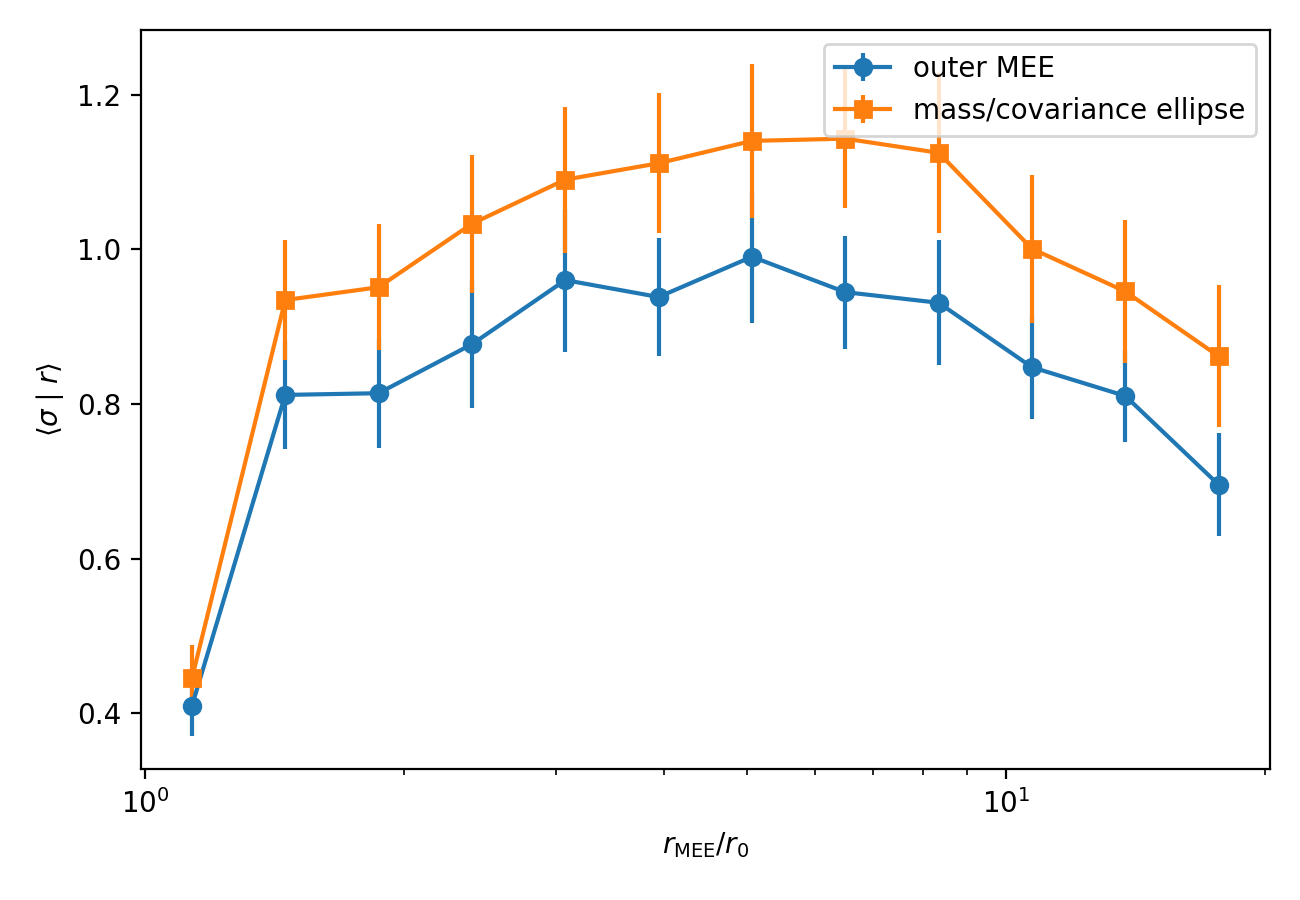

B1_residual_decomposition.png


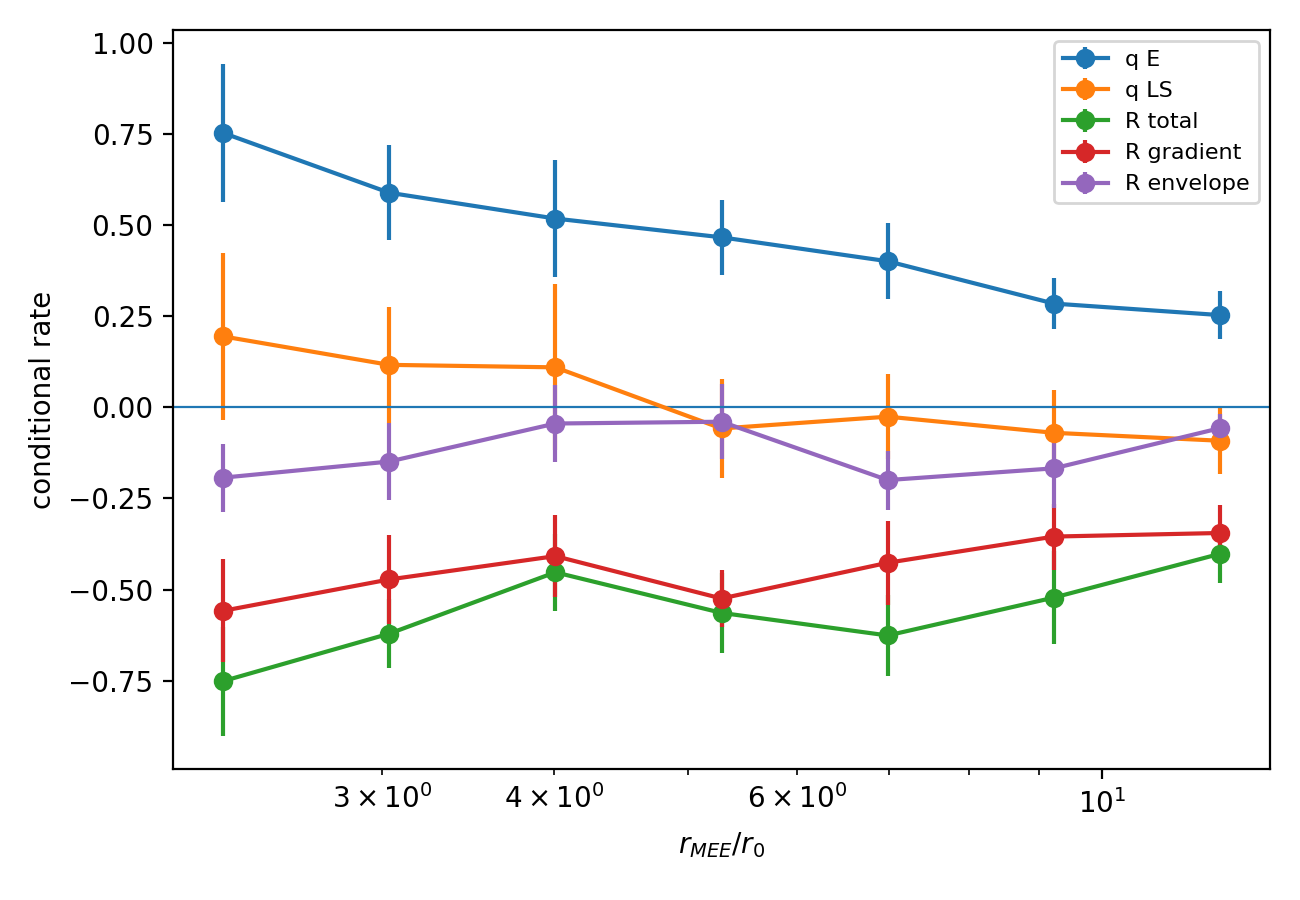

B3_MEE_robustness.png


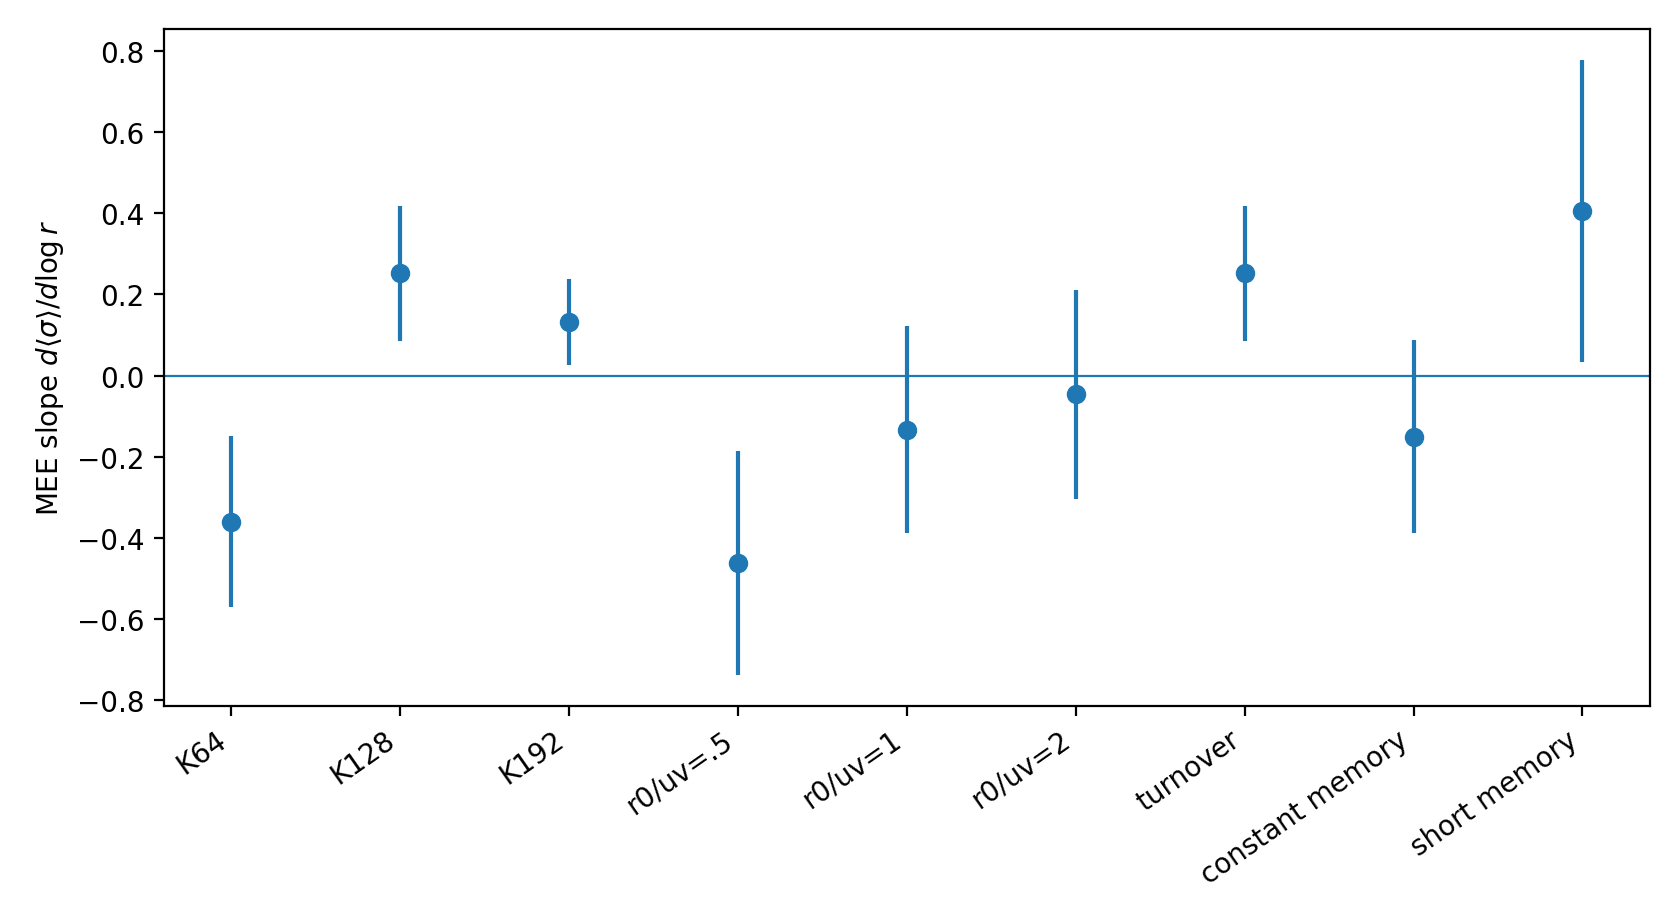

In [5]:
from IPython.display import display, Image
for name in ["B1_extended_aspect_ratios.png","B1_residual_decomposition.png","B3_MEE_robustness.png"]:
    path=ROOT/"figures"/"controls"/name
    if path.exists():
        print(name); display(Image(filename=str(path)))